In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, RepeatedKFold, cross_validate, learning_curve
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import KNNImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.cross_decomposition import PLSRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

## Chargement des données

In [2]:
filepath = r"C:\Users\melan\DESU_DATA_2026\ProjetNR\data2026.xlsx"
raw_df = pd.read_excel(filepath, engine="openpyxl", sheet_name='Total2', header=0,
                       na_values=['na', 'NaN', 'NA', 'N/A', 'n/a', 'nan'])
raw_df.head()

,Patient,Hipp,P300,P600,LNC,N400,LRC,IQ,VCI,PRI,WMI,SPI,VBL,VSL,VBD,VSD,OB,ON
0,2 D,NI,-68.8,82.60,-54.1,NaN,NaN,96.0,98.0,100.0,91.0,94.0,105.0,123.0,101.0,115.0,98%,80/77
1,3 G,NI,-44.7,80.00,-46.9,0.0,4.69,122.0,116.0,124.0,120.0,105.0,105.0,103.0,104.0,103.0,NaN,NaN
2,4 D,NI,-108.1,96.40,-26.6,-50.7,-0.55,86.0,82.0,94.0,86.0,100.0,79.0,91.0,69.0,88.0,98%,62/70
3,6 D,NI,-35.3,0.00,0.0,23.7,-0.30,67.0,71.0,86.0,68.0,64.0,102.0,85.0,104.0,85.0,88%,53/69
4,6 G,NI,-38.7,42.14,0.0,NaN,NaN,67.0,71.0,86.0,68.0,64.0,102.0,85.0,104.0,85.0,88%,53/69


## Split train / test — AVANT tout pretraitement

Règle d'or : **aucune information du test (y compris la cible) ne doit jamais entrer dans
le fit d'un encodeur, d'un imputer, d'un scaler ou d'un modèle.**
On sépare donc X (prédicteurs uniquement, sans VBL) et y (la cible) tout de suite,
puis on fait le split.

In [3]:
predictor_columns = ["P300", "P600", "LNC", "N400", "LRC", "OB", "ON", "Hipp"]
target_column = "WMI"

X = raw_df[predictor_columns].copy()
y = raw_df[target_column].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42
)

X_train.shape, X_test.shape

((43, 8), (22, 8))

## Encodage de `Hipp`

L'encodeur est **fit uniquement sur `X_train`**, puis simplement appliqué (`transform`) sur
`X_test` avec `handle_unknown="ignore"` au cas où une catégorie rare n'apparaîtrait que dans le test.

In [4]:
def encode_hipp(df, encoder, fit=False):
    df = df.copy()
    if fit:
        encoded = encoder.fit_transform(df[["Hipp"]])
    else:
        encoded = encoder.transform(df[["Hipp"]])
    hipp_columns = encoder.get_feature_names_out(["Hipp"])
    encoded_df = pd.DataFrame(encoded, columns=hipp_columns, index=df.index)
    return pd.concat([df.drop(columns=["Hipp"]), encoded_df], axis=1)

hipp_encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")

X_train = encode_hipp(X_train, hipp_encoder, fit=True)
X_test = encode_hipp(X_test, hipp_encoder, fit=False)

X_train.head()

,P300,P600,LNC,N400,LRC,OB,ON,Hipp_NI,Hipp_ZE,Hipp_ZP
4,-38.7,42.14,0.0,NaN,NaN,88%,53/69,1.0,0.0,0.0
48,0.0,157.90,-39.7,-31.9,0.0,NaN,NaN,0.0,1.0,0.0
36,-103.5,184.60,-62.4,-26.7,0.0,NaN,NaN,0.0,1.0,0.0
19,-293.4,50.60,-39.3,-27.8,6.4,1,NaN,0.0,0.0,1.0
55,0.0,0.00,-66.5,-20.2,0.0,1,57/78,0.0,1.0,0.0


## Nettoyage des données (colonnes trop incomplètes)

Le seuil de suppression est calculé **uniquement sur `X_train`**. La même liste de colonnes
est ensuite retirée de `X_test`, pour garantir des colonnes identiques des deux côtés
sans jamais regarder les valeurs du test pour décider quoi supprimer.

In [5]:
percent_missing = X_train.isnull().sum() * 100 / len(X_train)
percent_missing.sort_values(ascending=False, inplace=True)
percent_missing

ON         65.116279
OB         62.790698
LRC        30.232558
N400       30.232558
P600        4.651163
P300        4.651163
LNC         4.651163
Hipp_NI     0.000000
Hipp_ZE     0.000000
Hipp_ZP     0.000000
dtype: float64

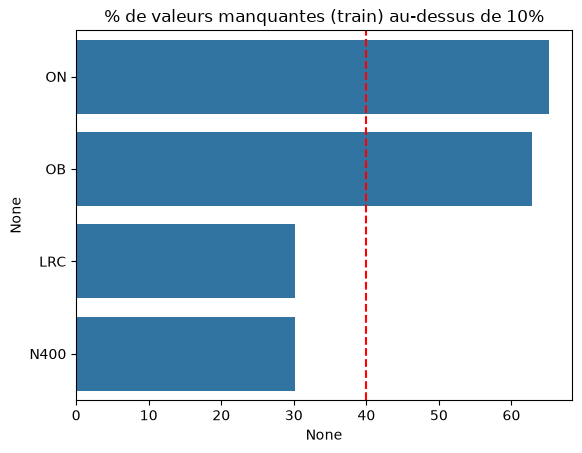

In [6]:
threshold_view = 10
filtered = percent_missing[percent_missing.values > threshold_view]

if len(filtered) > 0:
    ax = sns.barplot(x=filtered, y=filtered.index, orient='h')
    ax.set_title(f"% de valeurs manquantes (train) au-dessus de {threshold_view}%")
    threshold = 40
    ax.axvline(x=threshold, color='r', linestyle='--', label=f"Seuil de {threshold}")
else:
    threshold = 40
    print("Aucune colonne au-dessus du seuil d'affichage.")

In [7]:
columns_to_drop = percent_missing[percent_missing.values > threshold].index

X_train = X_train.drop(columns=columns_to_drop, errors="ignore")
X_test = X_test.drop(columns=columns_to_drop, errors="ignore")

columns_to_drop, X_train.shape, X_test.shape

(Index(['ON', 'OB'], dtype='str'), (43, 8), (22, 8))

## Imputation des valeurs manquantes

**Point critique corrigé :** le `KNNImputer` est fit **uniquement sur les prédicteurs de
`X_train` (jamais sur `VBL`)**. Le même imputer (déjà entraîné) est ensuite juste appliqué
(`transform`, pas `fit_transform`) sur `X_test` — sans jamais avoir besoin d'y injecter la
vraie valeur de la cible.

In [8]:
numeric_columns = X_train.select_dtypes(include=["float", "int"]).columns

imputer = KNNImputer(missing_values=np.nan)
imputer.fit(X_train[numeric_columns])

X_train_imputed = X_train.copy()
X_train_imputed[numeric_columns] = imputer.transform(X_train[numeric_columns])

X_test_imputed = X_test.copy()
X_test_imputed[numeric_columns] = imputer.transform(X_test[numeric_columns])

X_train_imputed.shape, X_test_imputed.shape

((43, 8), (22, 8))

### Retirer les lignes ou la cible (VBL) est manquante

On n'impute jamais la variable a predire : impossible d'entrainer ou d'evaluer sur une ligne
dont on ne connait pas la vraie reponse. On filtre donc train et test separement.

In [9]:
train_mask = y_train.notna()
test_mask = y_test.notna()

print(f"Lignes retirees (train, VBL manquant) : {(~train_mask).sum()}")
print(f"Lignes retirees (test, VBL manquant)  : {(~test_mask).sum()}")

X_train_imputed = X_train_imputed.loc[train_mask]
y_train = y_train.loc[train_mask]

X_test_imputed = X_test_imputed.loc[test_mask]
y_test = y_test.loc[test_mask]

X_train_imputed.shape, X_test_imputed.shape

Lignes retirees (train, VBL manquant) : 2
Lignes retirees (test, VBL manquant)  : 0


((41, 8), (22, 8))

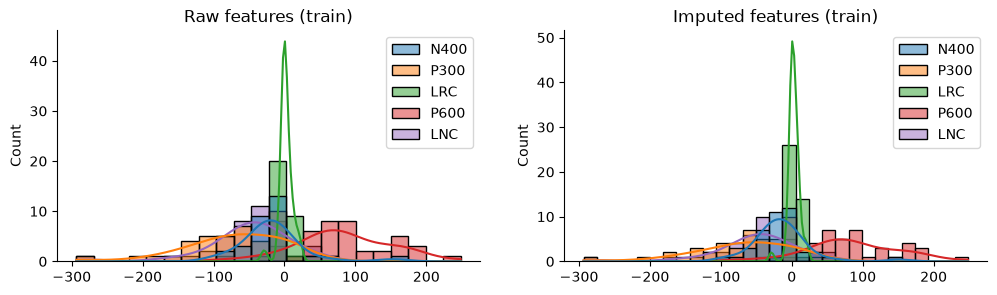

In [10]:
def compare_dist(features):
    fig, axes = plt.subplots(1, 2, figsize=(12, 3))
    sns.histplot(X_train.loc[:, features], kde=True, ax=axes[0])
    axes[0].set_title("Raw features (train)")
    sns.histplot(X_train_imputed.loc[:, features], kde=True, ax=axes[1])
    axes[1].set_title("Imputed features (train)")
    for ax in axes:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

compare_dist(["N400", "P300", "LRC", "P600", "LNC"])

## Modélisation — validation croisée strictement sur le TRAIN

**Point critique corrigé :** la comparaison des modèles se fait désormais sur
`X_train_imputed` / `y_train` (et non plus sur le test). Le `StandardScaler` reste dans
la `Pipeline` pour être re-fit à chaque pli de la CV, sans toucher aux autres plis.
Le test (`X_test_imputed`, `y_test`) reste intouché jusqu'à l'évaluation finale.

In [11]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.1, max_iter=10000),
    "Elastic Net": ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=10000),
    "PLS Regression": PLSRegression(n_components=2),
    "SVR": SVR(kernel="rbf", C=1, epsilon=0.1),
    "Random Forest": RandomForestRegressor(n_estimators=300, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
}

cv = RepeatedKFold(n_splits=5, n_repeats=10, random_state=42)

results = []

for name, model in models.items():
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("model", model),
    ])

    scores = cross_validate(
        pipeline,
        X_train_imputed,
        np.ravel(y_train),
        cv=cv,
        scoring={"R2": "r2", "RMSE": "neg_root_mean_squared_error", "MAE": "neg_mean_absolute_error"},
        return_train_score=False,
    )

    results.append({
        "Model": name,
        "R2_mean": np.mean(scores["test_R2"]),
        "R2_std": np.std(scores["test_R2"]),
        "RMSE_mean": -np.mean(scores["test_RMSE"]),
        "MAE_mean": -np.mean(scores["test_MAE"]),
    })

results_df = pd.DataFrame(results).sort_values("R2_mean", ascending=False).reset_index(drop=True)
results_df

,Model,R2_mean,R2_std,RMSE_mean,MAE_mean
0,SVR,-0.167310,0.196450,16.948120,13.812871
1,Random Forest,-0.504182,0.468718,18.802917,15.369587
2,Elastic Net,-0.514772,0.536881,18.990537,15.995769
3,Ridge,-0.542613,0.570124,19.133822,16.174574
4,Lasso,-0.568743,0.592899,19.276673,16.304712
5,Linear Regression,-0.585754,0.615284,19.358175,16.435187
6,PLS Regression,-0.613804,0.641658,19.481800,16.269259
7,Gradient Boosting,-0.812372,0.966086,20.028900,16.185164


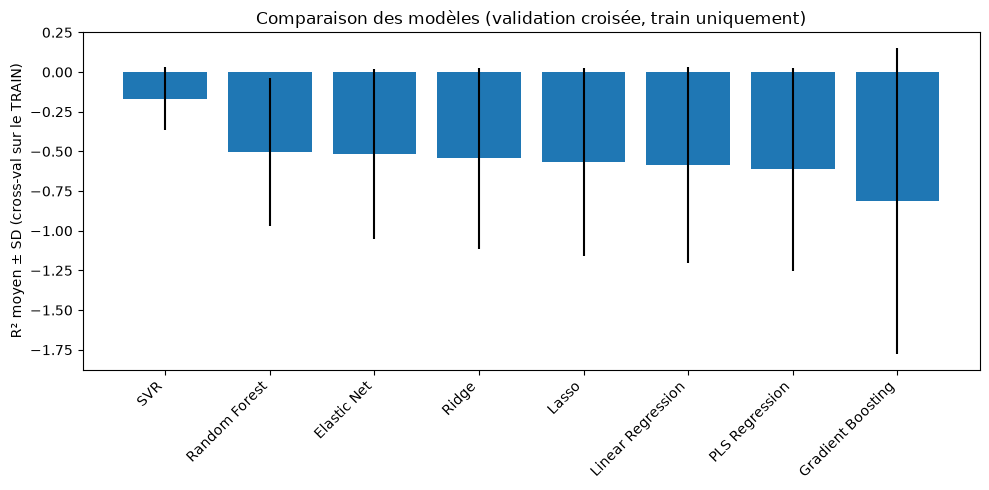

In [12]:
plt.figure(figsize=(10, 5))
plt.bar(results_df["Model"], results_df["R2_mean"], yerr=results_df["R2_std"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("R² moyen ± SD (cross-val sur le TRAIN)")
plt.title("Comparaison des modèles (validation croisée, train uniquement)")
plt.tight_layout()
plt.show()

## Sélection du meilleur modèle et évaluation UNIQUE sur le test

Le modèle est choisi selon le meilleur `R2_mean` en CV **sur le train**. On l'entraîne
ensuite une seule fois sur tout le train, puis on l'évalue **une seule fois** sur le test —
c'est la seule métrique qui compte pour juger de la performance réelle hors échantillon.

In [13]:
best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]

final_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", best_model),
])

final_pipeline.fit(X_train_imputed, np.ravel(y_train))
y_pred_test = final_pipeline.predict(X_test_imputed)

test_r2 = r2_score(y_test, y_pred_test)
test_rmse = root_mean_squared_error(y_test, y_pred_test)
test_mae = mean_absolute_error(y_test, y_pred_test)

print(f"Meilleur modèle (sélectionné sur le train) : {best_model_name}")
print(f"Performance sur le TEST (jamais vu avant) :")
print(f"  R²   = {test_r2:.3f}")
print(f"  RMSE = {test_rmse:.3f}")
print(f"  MAE  = {test_mae:.3f}")

Meilleur modèle (sélectionné sur le train) : SVR
Performance sur le TEST (jamais vu avant) :
  R²   = 0.014
  RMSE = 14.700
  MAE  = 11.627


## Learning curve du modèle réellement retenu (sur le train)

Contrairement à l'original (qui utilisait la variable `model` restée sur le dernier tour
de boucle, donc Gradient Boosting par accident), on utilise ici explicitement
`final_pipeline` / `best_model_name`.

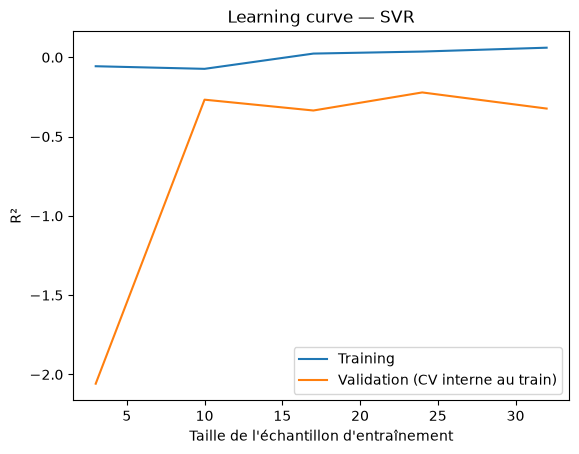

In [14]:
train_sizes, train_scores, val_scores = learning_curve(
    final_pipeline,
    X_train_imputed,
    np.ravel(y_train),
    cv=5,
    scoring="r2",
    train_sizes=np.linspace(0.1, 1.0, 5),
)

plt.plot(train_sizes, np.mean(train_scores, axis=1), label="Training")
plt.plot(train_sizes, np.mean(val_scores, axis=1), label="Validation (CV interne au train)")
plt.xlabel("Taille de l'échantillon d'entraînement")
plt.ylabel("R²")
plt.title(f"Learning curve — {best_model_name}")
plt.legend()
plt.show()